## Preliminares

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PowerTransformer
import sklearn.impute as skl_imp
from sklearn.experimental import enable_iterative_imputer # Necesario para usar skl_imp, no borrar
from src.config import data_folder
from src.funcionesTransform import *

In [2]:
# Abrir archivo raw_data
df = pd.read_parquet(f"{data_folder}/raw_data.parquet")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18016 entries, 0 to 18015
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    18016 non-null  datetime64[ns]
 1   Close                   18016 non-null  float64       
 2   Dividends               18016 non-null  float64       
 3   Ticker                  18016 non-null  object        
 4   Sector                  18016 non-null  object        
 5   DateAdded               18016 non-null  object        
 6   TotalRevenue            18016 non-null  float64       
 7   GrossProfit             17755 non-null  float64       
 8   OperatingIncome         18016 non-null  float64       
 9   NetIncome               17977 non-null  float64       
 10  EBITDA                  18016 non-null  float64       
 11  BasicAverageShares      17965 non-null  float64       
 12  CashAndCashEquivalents  17977 non-null  float6

In [3]:
# Valores missing
df.apply(lambda x: x.isna().sum() / len(x)).sort_values(ascending=False)

CurrentDebt               0.163355
LongTermDebt              0.053175
CapitalExpenditure        0.019427
GrossProfit               0.014487
TotalDebt                 0.003497
BasicAverageShares        0.002831
CashAndCashEquivalents    0.002165
NetIncome                 0.002165
StockholdersEquity        0.002165
OperatingCashFlow         0.002165
TotalRevenue              0.000000
DateAdded                 0.000000
Sector                    0.000000
Dividends                 0.000000
Ticker                    0.000000
Close                     0.000000
Date                      0.000000
OperatingIncome           0.000000
EBITDA                    0.000000
CurrentAssets             0.000000
TotalAssets               0.000000
CurrentLiabilities        0.000000
InvestingCashFlow         0.000000
FinancingCashFlow         0.000000
FreeCashFlow              0.000000
dtype: float64

In [4]:
# Se imputan gran parte de los NaNs en variables de Deuda antes de calcular métricas, 
# mediante sus relaciones contables.
df_debt_imputed = imputar_deuda(df)
df_debt_imputed.apply(lambda x: x.isna().sum() / len(x)).sort_values(ascending=False)

LongTermDebt              0.043850
CurrentDebt               0.043850
CapitalExpenditure        0.019427
GrossProfit               0.014487
TotalDebt                 0.003497
BasicAverageShares        0.002831
CashAndCashEquivalents    0.002165
NetIncome                 0.002165
StockholdersEquity        0.002165
OperatingCashFlow         0.002165
TotalRevenue              0.000000
DateAdded                 0.000000
Sector                    0.000000
Dividends                 0.000000
Ticker                    0.000000
Close                     0.000000
Date                      0.000000
OperatingIncome           0.000000
EBITDA                    0.000000
CurrentAssets             0.000000
TotalAssets               0.000000
CurrentLiabilities        0.000000
InvestingCashFlow         0.000000
FinancingCashFlow         0.000000
FreeCashFlow              0.000000
dtype: float64

In [5]:
# Calcular métricas
df_with_metrics, crecimiento_cols = calcular_metricas(df_debt_imputed)
df_with_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18016 entries, 0 to 18015
Data columns (total 47 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    18016 non-null  datetime64[ns]
 1   Close                   18016 non-null  float64       
 2   Dividends               18016 non-null  float64       
 3   Ticker                  18016 non-null  object        
 4   Sector                  18016 non-null  object        
 5   DateAdded               18016 non-null  object        
 6   TotalRevenue            18016 non-null  float64       
 7   GrossProfit             17755 non-null  float64       
 8   OperatingIncome         18016 non-null  float64       
 9   NetIncome               17977 non-null  float64       
 10  EBITDA                  18016 non-null  float64       
 11  BasicAverageShares      17965 non-null  float64       
 12  CashAndCashEquivalents  17977 non-null  float6

In [6]:
# Se aplica imputación transversal para las columnas de crecimiento
df_with_metrics = imputar_transversal(df_with_metrics, crecimiento_cols)
df_with_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18016 entries, 0 to 18015
Data columns (total 47 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    18016 non-null  datetime64[ns]
 1   Close                   18016 non-null  float64       
 2   Dividends               18016 non-null  float64       
 3   Ticker                  18016 non-null  object        
 4   Sector                  18016 non-null  object        
 5   DateAdded               18016 non-null  object        
 6   TotalRevenue            18016 non-null  float64       
 7   GrossProfit             17755 non-null  float64       
 8   OperatingIncome         18016 non-null  float64       
 9   NetIncome               17977 non-null  float64       
 10  EBITDA                  18016 non-null  float64       
 11  BasicAverageShares      17965 non-null  float64       
 12  CashAndCashEquivalents  17977 non-null  float6

In [7]:
# Calcular los retornos mensuales, varianza del activo y covarianza con el mercado para cada ticker
# Se abre el fichero de precios del Índice del Mercado
df_index = pd.read_parquet(f"{data_folder}/market_index.parquet")
df_with_features = calcular_retornos(df_with_metrics, df_index)
df_with_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18016 entries, 0 to 18015
Data columns (total 50 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Date                    18016 non-null  datetime64[ns]
 1   Close                   18016 non-null  float64       
 2   Dividends               18016 non-null  float64       
 3   Ticker                  18016 non-null  object        
 4   Sector                  18016 non-null  object        
 5   DateAdded               18016 non-null  object        
 6   TotalRevenue            18016 non-null  float64       
 7   GrossProfit             17755 non-null  float64       
 8   OperatingIncome         18016 non-null  float64       
 9   NetIncome               17977 non-null  float64       
 10  EBITDA                  18016 non-null  float64       
 11  BasicAverageShares      17965 non-null  float64       
 12  CashAndCashEquivalents  17977 non-null  float6

## Missing Values

In [8]:
# Incidencia de missings en columnas numéricas
df_cont = df_with_features.select_dtypes(include='number')
df_cont.apply(lambda x: x.isna().sum() / len(x)).sort_values(ascending=False)

MonthlyVariance           0.075766
MonthlyReturn             0.075766
MarketCovariance          0.075766
LongTermDebt              0.043850
CurrentDebt               0.043850
CapitalExpenditure        0.019427
CapExToRevenue            0.019427
GrossProfit               0.014487
TrailingPE                0.004996
PriceToBook               0.004996
ReturnOnEquity            0.004329
TotalDebt                 0.003497
BasicAverageShares        0.002831
EnterpriseValue           0.002831
EnterpriseToEbitda        0.002831
MarketCap                 0.002831
NetIncome                 0.002165
DebtToEquity              0.002165
ReturnOnAssets            0.002165
ProfitMargins             0.002165
CashAndCashEquivalents    0.002165
StockholdersEquity        0.002165
NetDebtToEbitda           0.002165
OperatingCashFlow         0.002165
TotalAssets               0.000000
EBITDA                    0.000000
Dividends                 0.000000
Close                     0.000000
TotalRevenue        

In [9]:
# Incidencia de missings en columnas no numéricas
df_non_numeric = df_with_features.select_dtypes(exclude='number')
df_non_numeric.apply(lambda x: x.isna().sum() / len(x)).sort_values(ascending=False)

Date         0.0
Ticker       0.0
Sector       0.0
DateAdded    0.0
dtype: float64

In [10]:
# NaN Restantes: Imputación multivariable con IterativeImputer sobre numéricas
# Imputador: Chain equations
imputer_itImp = skl_imp.IterativeImputer(max_iter=10, random_state=0)

df_cont_imputed = pd.DataFrame(imputer_itImp.fit_transform(df_cont),columns=df_cont.columns)
df_cont_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18016 entries, 0 to 18015
Data columns (total 46 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Close                   18016 non-null  float64
 1   Dividends               18016 non-null  float64
 2   TotalRevenue            18016 non-null  float64
 3   GrossProfit             18016 non-null  float64
 4   OperatingIncome         18016 non-null  float64
 5   NetIncome               18016 non-null  float64
 6   EBITDA                  18016 non-null  float64
 7   BasicAverageShares      18016 non-null  float64
 8   CashAndCashEquivalents  18016 non-null  float64
 9   CurrentDebt             18016 non-null  float64
 10  LongTermDebt            18016 non-null  float64
 11  TotalDebt               18016 non-null  float64
 12  StockholdersEquity      18016 non-null  float64
 13  TotalAssets             18016 non-null  float64
 14  CurrentAssets           18016 non-null

In [11]:
# Se vuelven a unir las columnas numéricas y no numéricas
df_imputed = pd.concat([df_cont_imputed, df_non_numeric], axis=1)
df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18016 entries, 0 to 18015
Data columns (total 50 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Close                   18016 non-null  float64       
 1   Dividends               18016 non-null  float64       
 2   TotalRevenue            18016 non-null  float64       
 3   GrossProfit             18016 non-null  float64       
 4   OperatingIncome         18016 non-null  float64       
 5   NetIncome               18016 non-null  float64       
 6   EBITDA                  18016 non-null  float64       
 7   BasicAverageShares      18016 non-null  float64       
 8   CashAndCashEquivalents  18016 non-null  float64       
 9   CurrentDebt             18016 non-null  float64       
 10  LongTermDebt            18016 non-null  float64       
 11  TotalDebt               18016 non-null  float64       
 12  StockholdersEquity      18016 non-null  float6

## Transformaciones

In [12]:
# Se calculan tamaños relativos: RelativeAssets y RelativeRevenue
df_transformed = calcular_relative_size(df_imputed)

In [13]:
# Se expresan columnas monetarias en billions
cols_financieras = obtener_cols_financieras()
cols_monetarias = cols_financieras + [
    'MarketCap', 
    'EnterpriseValue', 
    'TotalMarketAssets', 
    'TotalMarketRevenue'
    ]

for col in cols_monetarias:
    df_transformed[col] = df_transformed[col] / 10**9

In [14]:
#  Pasar DateAdded a formato datetime y transformar a YearsSinceAdded
df_transformed['DateAdded'] = pd.to_datetime(df_transformed['DateAdded'], errors='coerce')
df_transformed['YearsSinceAdded'] = round(((pd.Timestamp.now() - df_transformed['DateAdded']).dt.days / 365.25), 0)
df_transformed.drop('DateAdded', axis=1, inplace=True)

In [15]:
# Convertir Sector a category
df_transformed['Sector'] = df_transformed['Sector'].astype('category')

# Valores unicos en Sector
df_transformed['Sector'].value_counts()

Sector
Industrials              3123
InformationTechnology    2881
HealthCare               2238
ConsumerDiscretionary    1900
ConsumerStaples          1454
Financials               1268
RealEstate               1209
Utilities                1174
Materials                1025
CommunicationServices     925
Energy                    819
Name: count, dtype: int64

In [16]:
# Distribución de variables contínuas
df_transformed.describe().round(4).T

,count,mean,min,25%,50%,75%,max,std
Close,18016.0,197.3409,1.388,63.0491,116.9391,217.334,9811.7998,411.1238
Dividends,18016.0,0.195,0.0,0.0,0.0,0.08,90.0,1.0181
TotalRevenue,18016.0,32.345,0.6316,5.8148,12.497,25.92,716.924,67.3587
GrossProfit,18016.0,11.539,-1.991,2.54,4.798,9.627,360.51,25.3735
OperatingIncome,18016.0,4.7869,-10.824,0.983,1.9242,4.192,133.05,11.7351
NetIncome,18016.0,3.4875,-18.756,0.6147,1.3165,3.0762,132.17,9.9469
EBITDA,18016.0,6.6146,-15.7861,1.3961,2.6363,6.169,180.698,14.827
BasicAverageShares,18016.0,0.7967,0.0029,0.1575,0.3358,0.7038,24.87,1.8622
CashAndCashEquivalents,18016.0,3.1649,-0.0031,0.4405,1.272,3.472,86.81,5.7189
CurrentDebt,18016.0,1.8053,-1.0386,0.1166,0.599,1.6018,87.339,5.2839


In [17]:
# Coeficientes de asimetría
df_transformed.select_dtypes(include="number").skew().sort_values(ascending=False)

Dividends                 62.875774
RelativeAssets            57.629054
RelativeRevenue           32.674207
FcfToEbitda               13.741704
Close                     13.147910
MonthlyVariance           10.783272
CurrentDebt                9.440234
PriceToBook                8.959150
Revenue_QoQ                8.380549
MarketCap                  8.281979
Ebitda_QoQ                 8.276503
EnterpriseValue            8.144211
BasicAverageShares         7.559295
NetIncome                  7.283210
OperatingIncome            7.021181
FreeCashFlow               6.887553
CurrentRatio               6.681274
OperatingCashFlow          6.631465
EBITDA                     6.396889
GrossProfit                6.279061
StockholdersEquity         5.844682
CashAndCashEquivalents     5.776718
TotalRevenue               5.110431
CurrentLiabilities         4.917274
Fcf_QoQ                    4.494026
Ebitda_YoY                 4.449503
CurrentAssets              4.332647
ReturnOnEquity             4

Cont


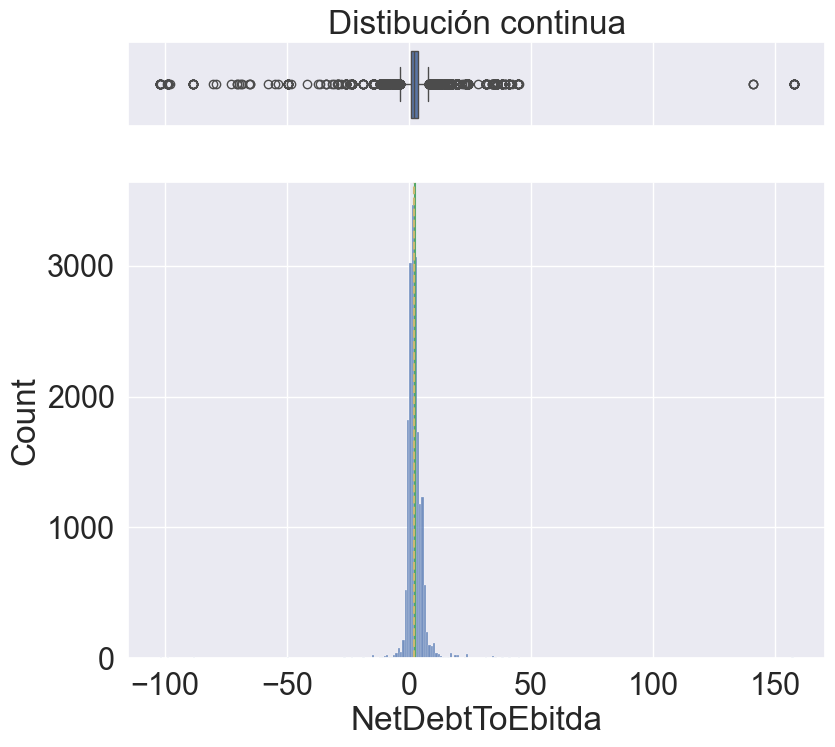

In [18]:
# Graficar
columna_a_graficar = 'NetDebtToEbitda' # indicar columna para el grafico
plot(df_transformed[columna_a_graficar])

In [19]:
# Transformaciones logarítmicas
columnas_a_transformar = [ 
    'CurrentRatio',
    'RelativeAssets',
    'RelativeRevenue'
    ]
for columna in columnas_a_transformar:
    df_transformed[f'{columna}_log'] = np.log(df_transformed[columna])
    df_transformed.drop(columna, axis=1, inplace=True)

# Coeficientes de asimetria actualizado
df_transformed.select_dtypes(include="number").skew().sort_values(ascending=False)

Dividends                 62.875774
FcfToEbitda               13.741704
Close                     13.147910
MonthlyVariance           10.783272
CurrentDebt                9.440234
PriceToBook                8.959150
Revenue_QoQ                8.380549
MarketCap                  8.281979
Ebitda_QoQ                 8.276503
EnterpriseValue            8.144211
BasicAverageShares         7.559295
NetIncome                  7.283210
OperatingIncome            7.021181
FreeCashFlow               6.887553
OperatingCashFlow          6.631465
EBITDA                     6.396889
GrossProfit                6.279061
StockholdersEquity         5.844682
CashAndCashEquivalents     5.776718
TotalRevenue               5.110431
CurrentLiabilities         4.917274
Fcf_QoQ                    4.494026
Ebitda_YoY                 4.449503
CurrentAssets              4.332647
ReturnOnEquity             4.153863
Revenue_YoY                4.118677
TotalAssets                3.691744
TotalDebt                  3

In [20]:
# Definir columnas que saltean la "winsorización"
columnas_intactas = cols_monetarias + [
    'Close',    
    'TrailingPE',
    'EnterpriseToEbitda',
    'PriceToBook',
    'Date', 
    'Ticker',
    'Dividends'        
    ]

# Separar el dataset
df_passthrough = df_transformed[columnas_intactas].copy()
df_transformed_features = df_transformed.drop(columns=columnas_intactas)

## Gestión de Outliers

Se winsorizan los valores atipicos en las variables continuas que cumplan los siguientes criterios:

Para variables simetricas:
* A mas de 3 desviaciones tipicas de la media.
* Mas de 3 rangos intercuartilicos.

Para variables asimetricas (modulo del coeficiente de asimetrica mayor a 1):
* A mas de 3 MADs de la mediana.
* Mas de 3 rangos intercuartilicos.

In [21]:
# Outliers
df_cont_transformed = df_transformed_features.select_dtypes(include="number")
df_winsor = df_cont_transformed.apply(lambda x: gestiona_outliers(x, clas='winsor'))

OperatingMargins
ProfitMargins
ReturnOnEquity
ReturnOnAssets
DebtToEquity
Revenue_YoY
Revenue_QoQ
Ebitda_YoY
Ebitda_QoQ
Fcf_YoY
Fcf_QoQ
CapEx_YoY
CapEx_QoQ
NetDebtToEbitda
FcfToEbitda
CapExToRevenue
MonthlyReturn
MonthlyVariance
MarketCovariance
YearsSinceAdded
CurrentRatio_log
RelativeAssets_log
RelativeRevenue_log


In [22]:
# Coeficientes de asimetria luego de winsorizar
df_winsor.skew().sort_values(ascending=False)

CapEx_QoQ              2.618990
Fcf_QoQ                1.803934
MonthlyVariance        1.734763
CapExToRevenue         1.717006
YearsSinceAdded        1.028205
MarketCovariance       0.952638
RelativeRevenue_log    0.630072
ReturnOnAssets         0.567836
CurrentRatio_log       0.455493
OperatingMargins       0.454012
MonthlyReturn          0.433422
Fcf_YoY                0.433368
Ebitda_YoY             0.316978
NetDebtToEbitda        0.298268
Revenue_YoY            0.290654
RelativeAssets_log     0.272915
ProfitMargins          0.121860
DebtToEquity           0.103697
ReturnOnEquity         0.051548
FcfToEbitda           -0.238001
Ebitda_QoQ            -0.493248
CapEx_YoY             -0.706763
Revenue_QoQ           -2.344508
dtype: float64

Cont


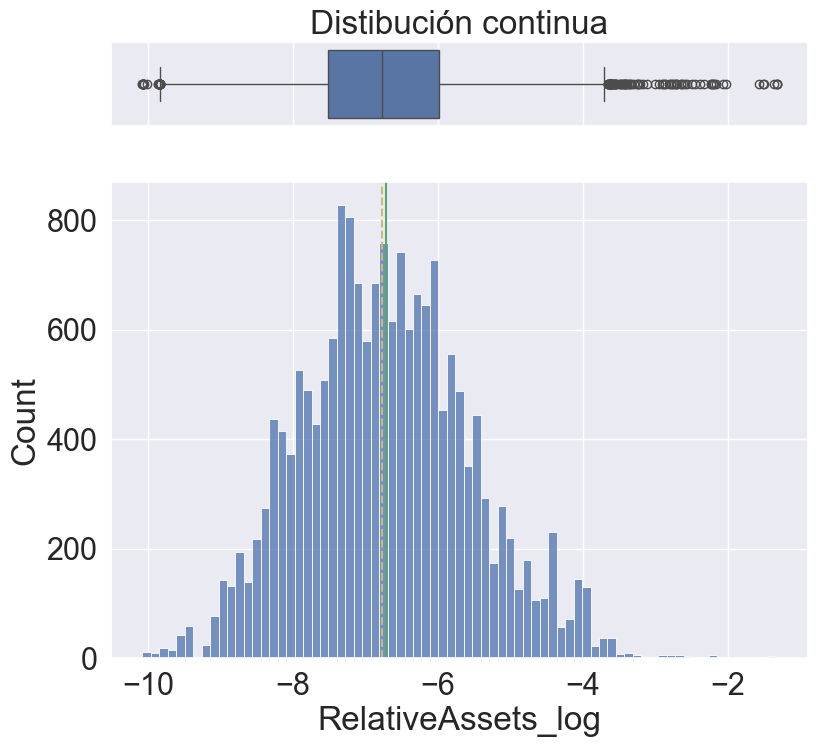

In [23]:
# Visualizar cambios
columna_a_graficar = 'RelativeAssets_log' # indicar columna para el grafico
plot(df_winsor[columna_a_graficar])

In [24]:
df_winsor.describe().T

,count,mean,std,min,25%,50%,75%,max
OperatingMargins,18016.0,1.893626e-01,0.141757,-0.398888,0.102016,0.177234,0.257621,0.741880
ProfitMargins,18016.0,1.343323e-01,0.130825,-0.353214,0.065358,0.120123,0.196847,0.603084
ReturnOnEquity,18016.0,1.868131e-01,0.308206,-0.600596,0.076367,0.158034,0.301991,0.981740
ReturnOnAssets,18016.0,7.849037e-02,0.077454,-0.227690,0.032310,0.062815,0.115621,0.388716
DebtToEquity,18016.0,9.333690e-01,1.545564,-3.052457,0.354537,0.720407,1.464997,4.798413
Revenue_YoY,18016.0,4.936207e-02,0.111137,-0.337165,-0.014486,0.050890,0.091761,0.439850
Revenue_QoQ,18016.0,1.552579e-07,0.000015,-0.000056,0.000000,0.000000,0.000000,0.000020
Ebitda_YoY,18016.0,7.807783e-02,0.241465,-0.521499,-0.009115,0.052889,0.159931,0.668003
Ebitda_QoQ,18016.0,1.257583e-05,0.000125,-0.000320,0.000000,0.000000,0.000000,0.000237
Fcf_YoY,18016.0,1.046481e-01,0.636228,-1.779000,-0.233857,0.039518,0.276144,1.866568


## Concatenación final de columnas

In [25]:
df_non_numeric_transformed = df_transformed_features.select_dtypes(exclude='number')
# Se unen variables contínuas transformadas y variables no numéricas
df_combined = pd.concat([df_non_numeric_transformed, df_winsor], axis=1)

# Unir con las columnas que fueron salteadas
df_final = pd.concat([df_passthrough, df_combined], axis=1)
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18016 entries, 0 to 18015
Data columns (total 54 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   CashAndCashEquivalents  18016 non-null  float64       
 1   CurrentDebt             18016 non-null  float64       
 2   LongTermDebt            18016 non-null  float64       
 3   TotalDebt               18016 non-null  float64       
 4   StockholdersEquity      18016 non-null  float64       
 5   TotalAssets             18016 non-null  float64       
 6   CurrentAssets           18016 non-null  float64       
 7   CurrentLiabilities      18016 non-null  float64       
 8   OperatingCashFlow       18016 non-null  float64       
 9   InvestingCashFlow       18016 non-null  float64       
 10  FinancingCashFlow       18016 non-null  float64       
 11  FreeCashFlow            18016 non-null  float64       
 12  CapitalExpenditure      18016 non-null  float6

In [26]:
# Guardar datos extraidos en fichero clean_data
df_final.to_parquet(f"{data_folder}/clean_data.parquet")